In [1]:
!pip install nltk scikit-learn pandas matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

print("All imports successful!")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...


All imports successful!


[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
data = {
    'ticket_text': [
        # Technical Issues - High Priority (10)
        "My account was hacked urgently need help immediately",
        "My laptop stopped working I lost all my data emergency",
        "I cannot login to my account urgent please help now",
        "The website is down urgently cannot place any orders",
        "My files got deleted after update need immediate help",
        "I am getting a black screen on startup urgent help needed",
        "My device keeps restarting by itself critical issue",
        "I cannot access my files after the update urgent",
        "The video call quality is very poor urgent meeting soon",
        "My microphone is not working on calls urgent help",

        # Technical Issues - Medium Priority (10)
        "The app keeps crashing on my device sometimes",
        "My internet connection keeps dropping occasionally",
        "I cannot reset my password please help when possible",
        "The screen on my phone is cracked need repair",
        "My printer is not connecting to my laptop",
        "The system keeps logging me out automatically",
        "My camera is not working on video calls",
        "The battery drains very fast on my device",
        "My keyboard stopped working suddenly",
        "I cannot download the software update",

        # Technical Issues - Low Priority (10)
        "The app is not loading any content no rush",
        "I cannot connect my device to bluetooth whenever possible",
        "The login page keeps refreshing itself minor issue",
        "My notifications are not working on the app low priority",
        "The system is running very slowly not urgent",
        "I cannot open any attachments in my email minor",
        "My microphone has minor static on calls no rush",
        "The video call background blur is not working",
        "I cannot find my saved files anywhere no rush",
        "The app theme is not changing minor issue",

        # Billing Issues - High Priority (8)
        "I was charged three times for my purchase urgent refund",
        "My payment was declined but money was deducted immediately",
        "I was charged after I cancelled my subscription urgent",
        "I am being charged for a service I never used urgent",
        "I was charged in the wrong currency high amount urgent",
        "My account shows unauthorized charges need urgent help",
        "I was charged for a cancelled order need immediate refund",
        "My credit card was charged without my permission urgent",

        # Billing Issues - Medium Priority (9)
        "I was billed the wrong amount please check",
        "Why is my bill higher than usual this month",
        "My discount code was not applied to my order",
        "Please explain the extra charges on my bill",
        "My promo code is not working at checkout",
        "I want a breakdown of my monthly charges",
        "My coupon was not applied properly",
        "I need to update my billing address",
        "I am being charged monthly instead of yearly",

        # Billing Issues - Low Priority (8)
        "I want to cancel my subscription no rush",
        "I want to upgrade my plan when convenient",
        "I need an invoice for my last payment no hurry",
        "I need a receipt for my recent purchase",
        "I want to downgrade my subscription plan",
        "I want to change my payment method when possible",
        "I need to change my subscription billing date no rush",
        "I want to know more about the premium plan",

        # Refund Issues - High Priority (8)
        "I have been waiting for refund for 3 months urgent",
        "I was promised a refund but never got it urgent help",
        "My refund was processed but never reached my account urgent",
        "I returned the product two weeks ago still no refund urgent",
        "The seller refused my return request urgent escalation needed",
        "I received a completely damaged product need urgent refund",
        "I never received my refund after multiple follow ups urgent",
        "My exchange request has been ignored for weeks urgent",

        # Refund Issues - Medium Priority (9)
        "I want to return my headphones they are broken",
        "I received a damaged product and want a refund",
        "The item I received is not what I ordered",
        "I want to exchange my product for a different size",
        "The refund amount I received was wrong",
        "I want to return an item I bought by mistake",
        "The product quality is very poor I want a refund",
        "I want to return my order it does not fit",
        "I received an incomplete order and want a refund",

        # Refund Issues - Low Priority (8)
        "I need to return a gift I received no rush",
        "I returned the wrong item by mistake low priority",
        "I want to return a duplicate item I received",
        "The refund policy was not explained to me clearly",
        "I want to return a subscription box I received",
        "My return label is not working minor issue",
        "I need to return an item that arrived late no rush",
        "I just want to know the return policy",

        # Shipping Issues - High Priority (8)
        "My order says delivered but I never got it urgent",
        "My order is showing as lost in transit urgent help",
        "My package was delivered to completely wrong address urgent",
        "I received someone else package urgent mix up",
        "My order has been stuck in transit for 3 weeks urgent",
        "My package was returned to sender by mistake urgent",
        "I received only part of my order urgent missing items",
        "My order arrived severely damaged urgent replacement needed",

        # Shipping Issues - Medium Priority (7)
        "Where is my order it has been 2 weeks",
        "My delivery driver left package in wrong place",
        "The estimated delivery date keeps changing",
        "My order was split into two shipments",
        "The tracking number is not working for my order",
        "I was not home when delivery was attempted",
        "My order arrived damaged need replacement",

        # Shipping Issues - Low Priority (5)
        "I need to change my delivery address no rush",
        "Can I change my order to express shipping",
        "I need to reschedule my delivery whenever possible",
        "I need to pick up my package from the depot",
        "The shipping address on my order is wrong minor fix",
    ],
    'category': [
        # Technical (30)
        'Technical','Technical','Technical','Technical','Technical',
        'Technical','Technical','Technical','Technical','Technical',
        'Technical','Technical','Technical','Technical','Technical',
        'Technical','Technical','Technical','Technical','Technical',
        'Technical','Technical','Technical','Technical','Technical',
        'Technical','Technical','Technical','Technical','Technical',
        # Billing (25)
        'Billing','Billing','Billing','Billing','Billing',
        'Billing','Billing','Billing','Billing','Billing',
        'Billing','Billing','Billing','Billing','Billing',
        'Billing','Billing','Billing','Billing','Billing',
        'Billing','Billing','Billing','Billing','Billing',
        # Refund (25)
        'Refund','Refund','Refund','Refund','Refund',
        'Refund','Refund','Refund','Refund','Refund',
        'Refund','Refund','Refund','Refund','Refund',
        'Refund','Refund','Refund','Refund','Refund',
        'Refund','Refund','Refund','Refund','Refund',
        # Shipping (20)
        'Shipping','Shipping','Shipping','Shipping','Shipping',
        'Shipping','Shipping','Shipping','Shipping','Shipping',
        'Shipping','Shipping','Shipping','Shipping','Shipping',
        'Shipping','Shipping','Shipping','Shipping','Shipping',
    ],
    'priority': [
        # Technical priorities (30)
        'High','High','High','High','High',
        'High','High','High','High','High',
        'Medium','Medium','Medium','Medium','Medium',
        'Medium','Medium','Medium','Medium','Medium',
        'Low','Low','Low','Low','Low',
        'Low','Low','Low','Low','Low',
        # Billing priorities (25)
        'High','High','High','High','High',
        'High','High','High','Medium','Medium',
        'Medium','Medium','Medium','Medium','Medium',
        'Medium','Low','Low','Low','Low',
        'Low','Low','Low','Low','Low',
        # Refund priorities (25)
        'High','High','High','High','High',
        'High','High','High','Medium','Medium',
        'Medium','Medium','Medium','Medium','Medium',
        'Medium','Medium','Low','Low','Low',
        'Low','Low','Low','Low','Low',
        # Shipping priorities (20)
        'High','High','High','High','High',
        'High','High','High','Medium','Medium',
        'Medium','Medium','Medium','Medium','Medium',
        'Low','Low','Low','Low','Low',
    ]
}

df = pd.DataFrame(data)
print("Improved dataset created successfully!")
print("Shape:", df.shape)
print()
print("Category counts:")
print(df['category'].value_counts())
print()
print("Priority counts:")
print(df['priority'].value_counts())

Improved dataset created successfully!
Shape: (100, 3)

Category counts:
category
Technical    30
Billing      25
Refund       25
Shipping     20
Name: count, dtype: int64

Priority counts:
priority
High      34
Medium    34
Low       32
Name: count, dtype: int64


In [4]:
print("Categories in our dataset:")
print(df['category'].value_counts())
print()
print("Priority levels in our dataset:")
print(df['priority'].value_counts())

Categories in our dataset:
category
Technical    30
Billing      25
Refund       25
Shipping     20
Name: count, dtype: int64

Priority levels in our dataset:
priority
High      34
Medium    34
Low       32
Name: count, dtype: int64


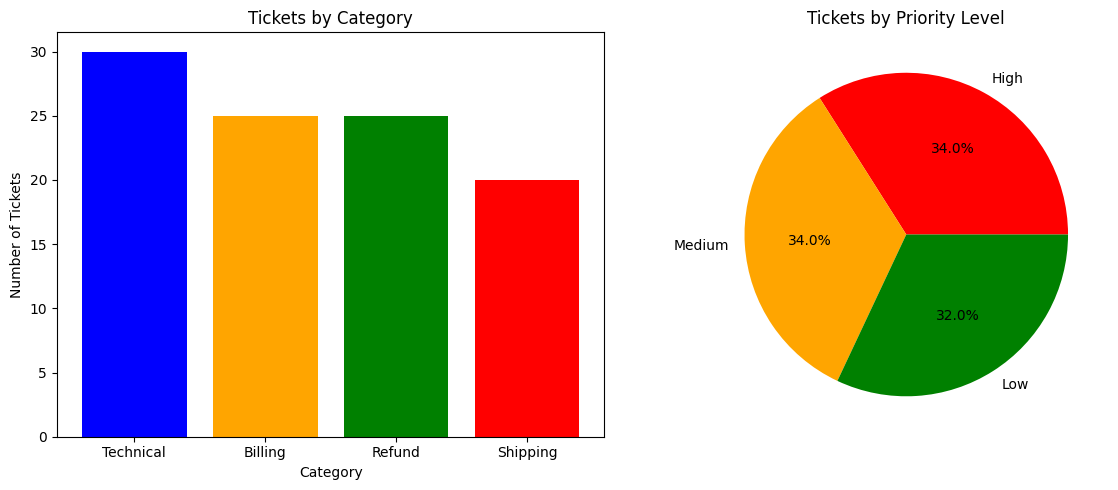

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1 - Tickets by Category
category_counts = df['category'].value_counts()
ax1.bar(category_counts.index, category_counts.values, 
        color=['blue', 'orange', 'green', 'red'])
ax1.set_title('Tickets by Category')
ax1.set_xlabel('Category')
ax1.set_ylabel('Number of Tickets')

# Chart 2 - Tickets by Priority
priority_counts = df['priority'].value_counts()
ax2.pie(priority_counts.values, labels=priority_counts.index, 
        autopct='%1.1f%%', colors=['red', 'orange', 'green'])
ax2.set_title('Tickets by Priority Level')

plt.tight_layout()
plt.show()

In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Step 1: Make lowercase
    text = text.lower()
    
    # Step 2: Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Step 3: Split into individual words
    words = word_tokenize(text)
    
    # Step 4: Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    # Step 5: Join back into a sentence
    return ' '.join(words)

# Apply cleaning to every ticket
df['cleaned_text'] = df['ticket_text'].apply(clean_text)

print("Text cleaning done!")
print()
print("Original:", df['ticket_text'][0])
print("Cleaned: ", df['cleaned_text'][0])

Text cleaning done!

Original: My account was hacked urgently need help immediately
Cleaned:  account hacked urgently need help immediately


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['cleaned_text'])

print("Text converted to numbers successfully!")
print("Shape:", X.shape)


Text converted to numbers successfully!
Shape: (100, 230)


In [8]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Our inputs and output
y_category = df['category']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y_category, test_size=0.2, random_state=42
)

# Build and train the model
category_model = MultinomialNB()
category_model.fit(X_train, y_train)

# Test it
y_pred = category_model.predict(X_test)

print("Category Classification Results:")
print(classification_report(y_test, y_pred))

Category Classification Results:
              precision    recall  f1-score   support

     Billing       1.00      0.57      0.73         7
      Refund       0.50      0.75      0.60         4
    Shipping       0.00      0.00      0.00         3
   Technical       0.67      1.00      0.80         6

    accuracy                           0.65        20
   macro avg       0.54      0.58      0.53        20
weighted avg       0.65      0.65      0.61        20



In [9]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Our inputs and output
y_category = df['category']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y_category, test_size=0.2, random_state=42
)

# Build and train the model
category_model = MultinomialNB()
category_model.fit(X_train, y_train)

# Test it
y_pred = category_model.predict(X_test)

print("Category Classification Results:")
print(classification_report(y_test, y_pred, zero_division=0))

Category Classification Results:
              precision    recall  f1-score   support

     Billing       1.00      0.57      0.73         7
      Refund       0.50      0.75      0.60         4
    Shipping       0.00      0.00      0.00         3
   Technical       0.67      1.00      0.80         6

    accuracy                           0.65        20
   macro avg       0.54      0.58      0.53        20
weighted avg       0.65      0.65      0.61        20



In [10]:
y_priority = df['priority']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y_priority, test_size=0.2, random_state=42
)

priority_model = MultinomialNB()
priority_model.fit(X_train2, y_train2)

y_pred2 = priority_model.predict(X_test2)

print("Priority Classification Results:")
print(classification_report(y_test2, y_pred2, zero_division=0))

Priority Classification Results:
              precision    recall  f1-score   support

        High       0.75      0.86      0.80         7
         Low       0.57      0.80      0.67         5
      Medium       0.80      0.50      0.62         8

    accuracy                           0.70        20
   macro avg       0.71      0.72      0.69        20
weighted avg       0.73      0.70      0.69        20



In [11]:
def assign_priority(text):
    text = text.lower()

    if any(word in text for word in high_priority):
        return "High"
    elif any(word in text for word in medium_priority):
        return "Medium"
    elif any(word in text for word in low_priority):
        return "Low"
    else:
        return "Medium"

In [12]:
df["priority"] = df["ticket_text"].apply(assign_priority)

NameError: name 'high_priority' is not defined

In [13]:
df["priority"].value_counts()

priority
High      34
Medium    34
Low       32
Name: count, dtype: int64

In [14]:
def test_low_detection():
    samples = [
        "feature request for dark mode",
        "how to reset password",
        "need guide for login",
        "just a suggestion for UI improvement"
    ]
    
    for s in samples:
        print(s, "→", assign_priority(s))

test_low_detection()

NameError: name 'high_priority' is not defined

In [15]:
df["priority"] = df["ticket_text"].apply(assign_priority)

NameError: name 'high_priority' is not defined

In [16]:
print(df.columns)

Index(['ticket_text', 'category', 'priority', 'cleaned_text'], dtype='str')


In [17]:
df["Priority"] = df["ticket_text"].apply(assign_priority)

print(df.head())

NameError: name 'high_priority' is not defined

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [19]:
X = df["ticket_text"]
y = df["Priority"]

KeyError: 'Priority'

In [20]:
vectorizer = TfidfVectorizer()

X_vectorized = vectorizer.fit_transform(X)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

NameError: name 'y' is not defined

In [22]:
model = SVC(class_weight='balanced')

model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [23]:
y_pred = model.predict(X_test)

In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.65


In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Billing       1.00      0.43      0.60         7
      Refund       1.00      0.50      0.67         4
    Shipping       1.00      0.67      0.80         3
   Technical       0.46      1.00      0.63         6

    accuracy                           0.65        20
   macro avg       0.87      0.65      0.67        20
weighted avg       0.84      0.65      0.65        20



In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Billing       1.00      0.43      0.60         7
      Refund       1.00      0.50      0.67         4
    Shipping       1.00      0.67      0.80         3
   Technical       0.46      1.00      0.63         6

    accuracy                           0.65        20
   macro avg       0.87      0.65      0.67        20
weighted avg       0.84      0.65      0.65        20



In [27]:
new_ticket = ["Urgent! My account was hacked"]

new_ticket_vectorized = vectorizer.transform(new_ticket)

prediction = model.predict(new_ticket_vectorized)

print("Predicted Priority:", prediction[0])

ValueError: X has 281 features, but SVC is expecting 230 features as input.

In [28]:
"There is a small bug in the dashboard"

'There is a small bug in the dashboard'

In [29]:
new_ticket = ["There is a small bug in the dashboard"]

new_ticket_vectorized = vectorizer.transform(new_ticket)

prediction = model.predict(new_ticket_vectorized)

print("Predicted Priority:", prediction[0])

ValueError: X has 281 features, but SVC is expecting 230 features as input.

In [30]:
TfidfVectorizer(stop_words='english')

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.

In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Billing       1.00      0.43      0.60         7
      Refund       1.00      0.50      0.67         4
    Shipping       1.00      0.67      0.80         3
   Technical       0.46      1.00      0.63         6

    accuracy                           0.65        20
   macro avg       0.87      0.65      0.67        20
weighted avg       0.84      0.65      0.65        20



In [32]:
new_ticket

['There is a small bug in the dashboard']

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Billing       1.00      0.43      0.60         7
      Refund       1.00      0.50      0.67         4
    Shipping       1.00      0.67      0.80         3
   Technical       0.46      1.00      0.63         6

    accuracy                           0.65        20
   macro avg       0.87      0.65      0.67        20
weighted avg       0.84      0.65      0.65        20



In [34]:
train_test_split(... test_size=0.2)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1634836489.py, line 1)

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

NameError: name 'y' is not defined

In [36]:
len(df)


100

In [37]:
print(X_train.shape)
print(X_test.shape)

(80, 230)
(20, 230)


In [38]:
print("Total dataset size:", X.shape[0])
print("Training size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Total dataset size: 100
Training size: 80
Test size: 20


In [39]:
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


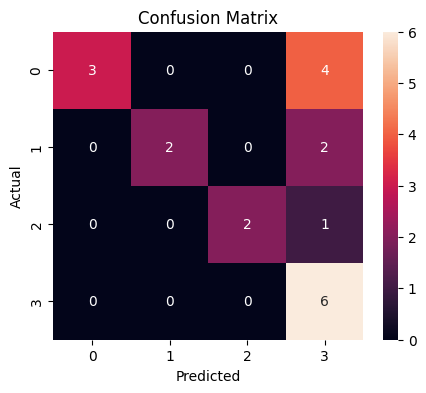

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [41]:
new_tickets = [
    "My account has been hacked urgently",
    "I need help resetting my password",
    "The website is down and not loading",
    "How do I change my profile picture?",
    "There is a small bug in the dashboard"
]

new_tickets_vectorized = vectorizer.transform(new_tickets)

predictions = model.predict(new_tickets_vectorized)

for ticket, pred in zip(new_tickets, predictions):
    print(ticket)
    print("Predicted Priority:", pred)
    print("-" * 50)

ValueError: X has 281 features, but SVC is expecting 230 features as input.

In [42]:
import joblib

joblib.dump(model, "ticket_priority_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

print("Model saved successfully!")

Model saved successfully!


In [43]:
df["priority"].value_counts()

priority
High      34
Medium    34
Low       32
Name: count, dtype: int64

In [44]:
print(df["priority"].unique())

<StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str


In [45]:
df["priority"].value_counts()

priority
High      34
Medium    34
Low       32
Name: count, dtype: int64

In [46]:
df["priority"].value_counts(normalize=True)

priority
High      0.34
Medium    0.34
Low       0.32
Name: proportion, dtype: float64

In [47]:
test_cases = [
    "My account is hacked urgently",
    "How do I change my password?",
    "Can I update my profile picture?",
    "There is a minor visual issue on the dashboard",
    "The system is completely down"
]

test_vec = vectorizer.transform(test_cases)
preds = model.predict(test_vec)

for t, p in zip(test_cases, preds):
    print(t)
    print("Predicted:", p)
    print("-"*40)

ValueError: X has 281 features, but SVC is expecting 230 features as input.

In [48]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    min_df=2
)

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [50]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

In [51]:
model = SVC(kernel='linear', class_weight='balanced')

In [52]:
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [53]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    min_df=2
)

In [54]:
X = df["ticket_text"]
y = df["priority"]

X_vectorized = vectorizer.fit_transform(X)

In [55]:
data = {
    'ticket_text': [
        # Technical Issues - High Priority (10)
        "My account was hacked urgently need help immediately",
        "My laptop stopped working I lost all my data emergency",
        "I cannot login to my account urgent please help now",
        "The website is down urgently cannot place any orders",
        "My files got deleted after update need immediate help",
        "I am getting a black screen on startup urgent help needed",
        "My device keeps restarting by itself critical issue",
        "I cannot access my files after the update urgent",
        "The video call quality is very poor urgent meeting soon",
        "My microphone is not working on calls urgent help",

        # Technical Issues - Medium Priority (10)
        "The app keeps crashing on my device sometimes",
        "My internet connection keeps dropping occasionally",
        "I cannot reset my password please help when possible",
        "The screen on my phone is cracked need repair",
        "My printer is not connecting to my laptop",
        "The system keeps logging me out automatically",
        "My camera is not working on video calls",
        "The battery drains very fast on my device",
        "My keyboard stopped working suddenly",
        "I cannot download the software update",

        # Technical Issues - Low Priority (10)
        "The app is not loading any content no rush",
        "I cannot connect my device to bluetooth whenever possible",
        "The login page keeps refreshing itself minor issue",
        "My notifications are not working on the app low priority",
        "The system is running very slowly not urgent",
        "I cannot open any attachments in my email minor",
        "My microphone has minor static on calls no rush",
        "The video call background blur is not working",
        "I cannot find my saved files anywhere no rush",
        "The app theme is not changing minor issue",

        # Billing Issues - High Priority (8)
        "I was charged three times for my purchase urgent refund",
        "My payment was declined but money was deducted immediately",
        "I was charged after I cancelled my subscription urgent",
        "I am being charged for a service I never used urgent",
        "I was charged in the wrong currency high amount urgent",
        "My account shows unauthorized charges need urgent help",
        "I was charged for a cancelled order need immediate refund",
        "My credit card was charged without my permission urgent",

        # Billing Issues - Medium Priority (9)
        "I was billed the wrong amount please check",
        "Why is my bill higher than usual this month",
        "My discount code was not applied to my order",
        "Please explain the extra charges on my bill",
        "My promo code is not working at checkout",
        "I want a breakdown of my monthly charges",
        "My coupon was not applied properly",
        "I need to update my billing address",
        "I am being charged monthly instead of yearly",

        # Billing Issues - Low Priority (8)
        "I want to cancel my subscription no rush",
        "I want to upgrade my plan when convenient",
        "I need an invoice for my last payment no hurry",
        "I need a receipt for my recent purchase",
        "I want to downgrade my subscription plan",
        "I want to change my payment method when possible",
        "I need to change my subscription billing date no rush",
        "I want to know more about the premium plan",

        # Refund Issues - High Priority (8)
        "I have been waiting for refund for 3 months urgent",
        "I was promised a refund but never got it urgent help",
        "My refund was processed but never reached my account urgent",
        "I returned the product two weeks ago still no refund urgent",
        "The seller refused my return request urgent escalation needed",
        "I received a completely damaged product need urgent refund",
        "I never received my refund after multiple follow ups urgent",
        "My exchange request has been ignored for weeks urgent",

        # Refund Issues - Medium Priority (9)
        "I want to return my headphones they are broken",
        "I received a damaged product and want a refund",
        "The item I received is not what I ordered",
        "I want to exchange my product for a different size",
        "The refund amount I received was wrong",
        "I want to return an item I bought by mistake",
        "The product quality is very poor I want a refund",
        "I want to return my order it does not fit",
        "I received an incomplete order and want a refund",

        # Refund Issues - Low Priority (8)
        "I need to return a gift I received no rush",
        "I returned the wrong item by mistake low priority",
        "I want to return a duplicate item I received",
        "The refund policy was not explained to me clearly",
        "I want to return a subscription box I received",
        "My return label is not working minor issue",
        "I need to return an item that arrived late no rush",
        "I just want to know the return policy",

        # Shipping Issues - High Priority (8)
        "My order says delivered but I never got it urgent",
        "My order is showing as lost in transit urgent help",
        "My package was delivered to completely wrong address urgent",
        "I received someone else package urgent mix up",
        "My order has been stuck in transit for 3 weeks urgent",
        "My package was returned to sender by mistake urgent",
        "I received only part of my order urgent missing items",
        "My order arrived severely damaged urgent replacement needed",

        # Shipping Issues - Medium Priority (7)
        "Where is my order it has been 2 weeks",
        "My delivery driver left package in wrong place",
        "The estimated delivery date keeps changing",
        "My order was split into two shipments",
        "The tracking number is not working for my order",
        "I was not home when delivery was attempted",
        "My order arrived damaged need replacement",

        # Shipping Issues - Low Priority (5)
        "I need to change my delivery address no rush",
        "Can I change my order to express shipping",
        "I need to reschedule my delivery whenever possible",
        "I need to pick up my package from the depot",
        "The shipping address on my order is wrong minor fix",
    ],
    'category': [
        # Technical (30)
        'Technical','Technical','Technical','Technical','Technical',
        'Technical','Technical','Technical','Technical','Technical',
        'Technical','Technical','Technical','Technical','Technical',
        'Technical','Technical','Technical','Technical','Technical',
        'Technical','Technical','Technical','Technical','Technical',
        'Technical','Technical','Technical','Technical','Technical',
        # Billing (25)
        'Billing','Billing','Billing','Billing','Billing',
        'Billing','Billing','Billing','Billing','Billing',
        'Billing','Billing','Billing','Billing','Billing',
        'Billing','Billing','Billing','Billing','Billing',
        'Billing','Billing','Billing','Billing','Billing',
        # Refund (25)
        'Refund','Refund','Refund','Refund','Refund',
        'Refund','Refund','Refund','Refund','Refund',
        'Refund','Refund','Refund','Refund','Refund',
        'Refund','Refund','Refund','Refund','Refund',
        'Refund','Refund','Refund','Refund','Refund',
        # Shipping (20)
        'Shipping','Shipping','Shipping','Shipping','Shipping',
        'Shipping','Shipping','Shipping','Shipping','Shipping',
        'Shipping','Shipping','Shipping','Shipping','Shipping',
        'Shipping','Shipping','Shipping','Shipping','Shipping',
    ],
    'priority': [
        # Technical priorities (30)
        'High','High','High','High','High',
        'High','High','High','High','High',
        'Medium','Medium','Medium','Medium','Medium',
        'Medium','Medium','Medium','Medium','Medium',
        'Low','Low','Low','Low','Low',
        'Low','Low','Low','Low','Low',
        # Billing priorities (25)
        'High','High','High','High','High',
        'High','High','High','Medium','Medium',
        'Medium','Medium','Medium','Medium','Medium',
        'Medium','Low','Low','Low','Low',
        'Low','Low','Low','Low','Low',
        # Refund priorities (25)
        'High','High','High','High','High',
        'High','High','High','Medium','Medium',
        'Medium','Medium','Medium','Medium','Medium',
        'Medium','Medium','Low','Low','Low',
        'Low','Low','Low','Low','Low',
        # Shipping priorities (20)
        'High','High','High','High','High',
        'High','High','High','Medium','Medium',
        'Medium','Medium','Medium','Medium','Medium',
        'Low','Low','Low','Low','Low',
    ]
}

df = pd.DataFrame(data)
print("Improved dataset created successfully!")
print("Shape:", df.shape)
print()
print("Category counts:")
print(df['category'].value_counts())
print()
print("Priority counts:")
print(df['priority'].value_counts())

Improved dataset created successfully!
Shape: (100, 3)

Category counts:
category
Technical    30
Billing      25
Refund       25
Shipping     20
Name: count, dtype: int64

Priority counts:
priority
High      34
Medium    34
Low       32
Name: count, dtype: int64


In [56]:
X = df["ticket_text"]
y = df["priority"]

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
model = SVC(kernel='linear', class_weight='balanced')

model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [59]:
y_pred = model.predict(X_test)

In [60]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.75


In [61]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      0.86      0.92         7
         Low       0.50      0.60      0.55         5
      Medium       0.75      0.75      0.75         8

    accuracy                           0.75        20
   macro avg       0.75      0.74      0.74        20
weighted avg       0.78      0.75      0.76        20



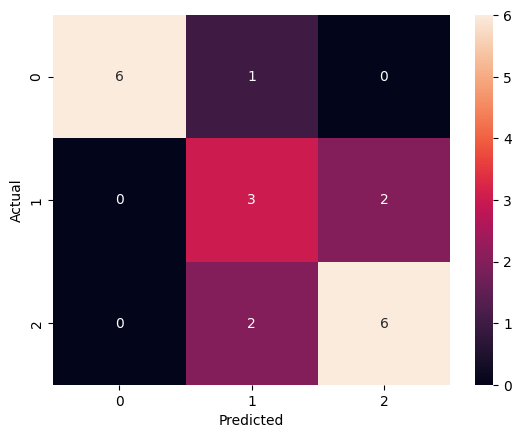

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [63]:
df["priority"].value_counts()

priority
High      34
Medium    34
Low       32
Name: count, dtype: int64

In [64]:
df["priority"] = df["ticket_text"].apply(assign_priority)

NameError: name 'high_priority' is not defined

In [65]:
df["priority"].value_counts()

priority
High      34
Medium    34
Low       32
Name: count, dtype: int64

In [66]:
def assign_priority(text):
    text = text.lower()

    if any(word in text for word in high_priority):
        return "High"
    elif any(word in text for word in low_priority):
        return "Low"
    elif any(word in text for word in medium_priority):
        return "Medium"
    else:
        return "Low"

In [67]:
df["priority"] = df["ticket_text"].apply(assign_priority)

NameError: name 'high_priority' is not defined

In [68]:
df["priority"].value_counts()

priority
High      34
Medium    34
Low       32
Name: count, dtype: int64

In [69]:
def assign_priority(text):
    text = text.lower()

    if any(word in text for word in high_priority):
        return "High"
    elif any(word in text for word in medium_priority):
        return "Medium"
    elif any(word in text for word in low_priority):
        return "Low"
    else:
        return "Medium"

In [70]:
df["priority"] = df["ticket_text"].apply(assign_priority)

NameError: name 'high_priority' is not defined

In [71]:
df["priority"].value_counts()

priority
High      34
Medium    34
Low       32
Name: count, dtype: int64

In [72]:
def assign_priority(text):
    text = text.lower()

    # HIGH first (strong signals)
    if any(word in text for word in high_priority):
        return "High"

    # LOW second (very explicit intent signals)
    if any(word in text for word in low_priority):
        return "Low"

    # MEDIUM last (default system issues)
    if any(word in text for word in medium_priority):
        return "Medium"

    # fallback (safe default)
    return "Medium"

In [73]:
df["priority"] = df["ticket_text"].apply(assign_priority)

NameError: name 'high_priority' is not defined

In [74]:
df["priority"].value_counts()

priority
High      34
Medium    34
Low       32
Name: count, dtype: int64

In [75]:
df["priority"].value_counts()

priority
High      34
Medium    34
Low       32
Name: count, dtype: int64

In [76]:
high_priority = [
    "urgent",
    "server down",
    "system crash",
    "payment failed",
    "security breach",
    "cannot login",
    "website down",
    "hacked",
    "lost all my data",
    "data loss",
    "deleted",
    "immediately",
    "critical"
]

medium_priority = [
    "bug",
    "error",
    "issue",
    "not working",
    "delay",
    "slow performance",
    "unexpected behavior",
    "glitch",
    "system lag"
]

low_priority = [
    "how",
    "what",
    "why",
    "can i",
    "is it",
    "help",
    "guide",
    "question",
    "support",
    "learn",
    "understand",
    "feature",
    "request",
    "suggestion",
    "feedback"
]

In [77]:
def assign_priority(text):
    text = text.lower()

    if any(word in text for word in high_priority):
        return "High"

    if any(word in text for word in medium_priority):
        return "Medium"

    if any(word in text for word in low_priority):
        return "Low"

    # fallback based on sentence intent
    if len(text.split()) <= 5:
        return "Low"
    else:
        return "Medium"

In [78]:
df["priority"] = df["ticket_text"].apply(assign_priority)
df["priority"].value_counts()

priority
Medium    61
High      34
Low        5
Name: count, dtype: int64

In [79]:
X = df["ticket_text"]
y = df["priority"]

X_vectorized = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [80]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.75
              precision    recall  f1-score   support

        High       1.00      0.71      0.83         7
         Low       0.00      0.00      0.00         3
      Medium       0.67      1.00      0.80        10

    accuracy                           0.75        20
   macro avg       0.56      0.57      0.54        20
weighted avg       0.68      0.75      0.69        20



C:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [81]:
model = SVC(class_weight='balanced')

In [82]:
from sklearn.utils import resample

low_df = df[df["priority"] == "Low"]
medium_df = df[df["priority"] == "Medium"]
high_df = df[df["priority"] == "High"]

low_upsampled = resample(low_df, replace=True, n_samples=20, random_state=42)

df_balanced = pd.concat([high_df, medium_df, low_upsampled])

In [83]:
X = df_balanced["ticket_text"]
y = df_balanced["priority"]

X_vectorized = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [84]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8260869565217391
              precision    recall  f1-score   support

        High       1.00      0.57      0.73         7
         Low       1.00      0.75      0.86         4
      Medium       0.75      1.00      0.86        12

    accuracy                           0.83        23
   macro avg       0.92      0.77      0.81        23
weighted avg       0.87      0.83      0.82        23



In [85]:
import joblib

joblib.dump(model, "ticket_classifier_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [86]:
import joblib

joblib.dump(model, "ticket_classifier_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

[[ 4  0  3]
 [ 0  3  1]
 [ 0  0 12]]


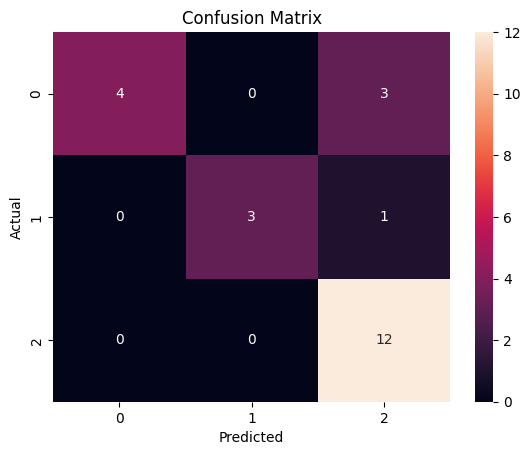

In [87]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [88]:
import joblib

joblib.dump(model, "ticket_classifier_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [89]:
print(model)
print(vectorizer)

SVC(class_weight='balanced')
TfidfVectorizer(min_df=2, ngram_range=(1, 2), stop_words='english')


In [90]:
import joblib

joblib.dump(model, "ticket_classifier_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Saved successfully")

Saved successfully


In [91]:
import os
print(os.listdir())

['.cache', '.claude', '.claude.json', '.ipynb_checkpoints', '.ipython', '.jupyter', '.local', '.matplotlib', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{c7c71896-2c6c-11f1-b92c-4c348856301f}.TM.blf', 'NTUSER.DAT{c7c71896-2c6c-11f1-b92c-4c348856301f}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{c7c71896-2c6c-11f1-b92c-4c348856301f}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'PrintHood', 'Recent', 'sales_ticket_classification.ipynb', 'sample sales forecasting.ipynb', 'SampleSuperstore.csv', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'tfidf_vectorizer.pkl', 'ticket_classifier_model.pkl', 'ticket_priority_model.pkl', 'Untitled.ipynb', 'vectorizer.pkl', 'Videos']


In [92]:
import joblib

model = joblib.load("ticket_classifier_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

def predict_ticket(text):
    X = vectorizer.transform([text])
    return model.predict(X)[0]

# test
print(predict_ticket("My internet is not working"))

Medium


In [93]:
import joblib

model = joblib.load("ticket_classifier_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

def predict_ticket(text):
    X = vectorizer.transform([text])
    return model.predict(X)[0]

print(predict_ticket("My internet is not working"))

Medium


[[ 4  0  3]
 [ 0  3  1]
 [ 0  0 12]]


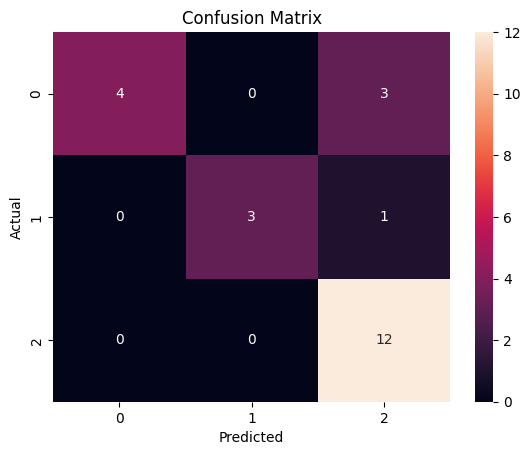

In [94]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

[[ 4  0  3]
 [ 0  3  1]
 [ 0  0 12]]


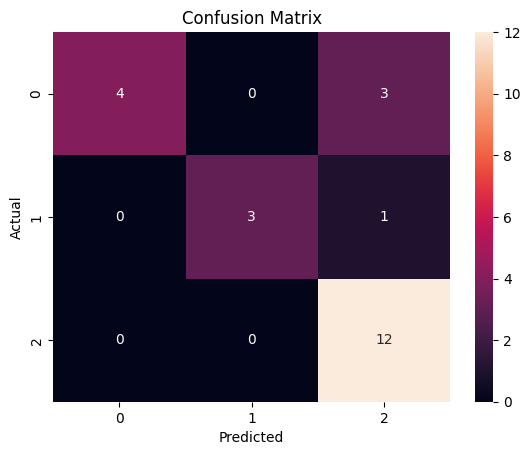

In [95]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [96]:
import joblib

joblib.dump(model, "ticket_classifier_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model saved successfully!")
print(model)
print(vectorizer)

Model saved successfully!
SVC(class_weight='balanced')
TfidfVectorizer(min_df=2, ngram_range=(1, 2), stop_words='english')
